<a href="https://colab.research.google.com/github/doannguyenminhtamcuc-ship-it/Data_VN_chapter1/blob/main/Ph%C3%A2n_t%C3%ADch_OECD_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

df = pd.read_csv('/content/Employment OECD INDUSTRY.csv')
display(df.head())

,Country,Year,Gender,Economic activity,Employment Thousands
0,OECD,2013,Female,A. Agriculture; forestry and fishing,7263.7368
1,OECD,2013,Female,C. Manufacturing,16442.3368
2,OECD,2013,Female,F. Construction,2332.8045
3,OECD,2013,Female,G. Wholesale and retail trade; repair of motor...,26490.8310
4,OECD,2013,Female,H. Transportation and storage,3015.7303


In [2]:
# Check for missing values
print("Missing values before filling:\n", df.isnull().sum())

# Fill missing values with the average of the previous and next year
for col in df.columns:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].interpolate(method='linear', limit_direction='both'))

print("\nMissing values after filling:\n", df.isnull().sum())

display(df.head())

Missing values before filling:
 Country                 0
Year                    0
Gender                  0
Economic activity       0
Employment Thousands    0
dtype: int64

Missing values after filling:
 Country                 0
Year                    0
Gender                  0
Economic activity       0
Employment Thousands    0
dtype: int64


,Country,Year,Gender,Economic activity,Employment Thousands
0,OECD,2013,Female,A. Agriculture; forestry and fishing,7263.7368
1,OECD,2013,Female,C. Manufacturing,16442.3368
2,OECD,2013,Female,F. Construction,2332.8045
3,OECD,2013,Female,G. Wholesale and retail trade; repair of motor...,26490.8310
4,OECD,2013,Female,H. Transportation and storage,3015.7303


In [3]:
# Pivot the data to have 'Female' and 'Male' employment as separate columns
pivot_df = df.pivot_table(
    index=['Country', 'Year', 'Economic activity'],
    columns='Gender',
    values='Employment Thousands'
).reset_index()

# Create the 'Female-Male Ratio' variable
pivot_df['Female-Male Ratio'] = pivot_df['Female'] / pivot_df['Male']

# Display the first few rows of the new dataframe with the calculated ratio
display(pivot_df.head())

Gender,Country,Year,Economic activity,Female,Male,Total,Female-Male Ratio
0,OECD,2013,A. Agriculture; forestry and fishing,7263.7368,15969.3436,27929.6343,0.454855
1,OECD,2013,C. Manufacturing,16442.3368,39826.7130,63303.3615,0.412847
2,OECD,2013,F. Construction,2332.8045,23211.0170,30045.4384,0.100504
3,OECD,2013,G. Wholesale and retail trade; repair of motor...,26490.8310,29400.1360,64784.6018,0.901045
4,OECD,2013,H. Transportation and storage,3015.7303,14168.3600,20455.4980,0.212850


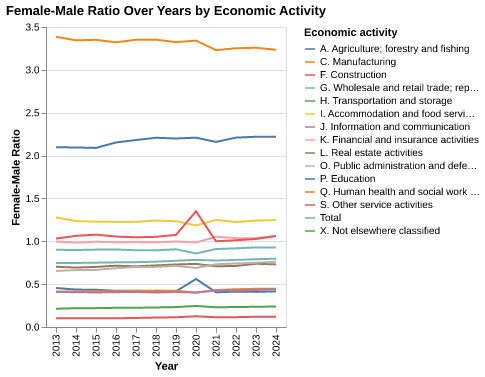

In [8]:
import altair as alt
from IPython.display import Image, display

# Install vl-convert-python for saving charts as PNG
!pip install vl-convert-python

# Create the line chart
chart = alt.Chart(pivot_df).mark_line().encode(
    x=alt.X('Year:O', title='Year'),
    y=alt.Y('Female-Male Ratio', title='Female-Male Ratio'),
    color='Economic activity:N',
    tooltip=['Year', 'Economic activity', 'Female-Male Ratio']
).properties(
    title='Female-Male Ratio Over Years by Economic Activity'
).interactive()

# Save chart as PNG
chart.save("chart.png")

# Display PNG image in notebook
display(Image("chart.png"))

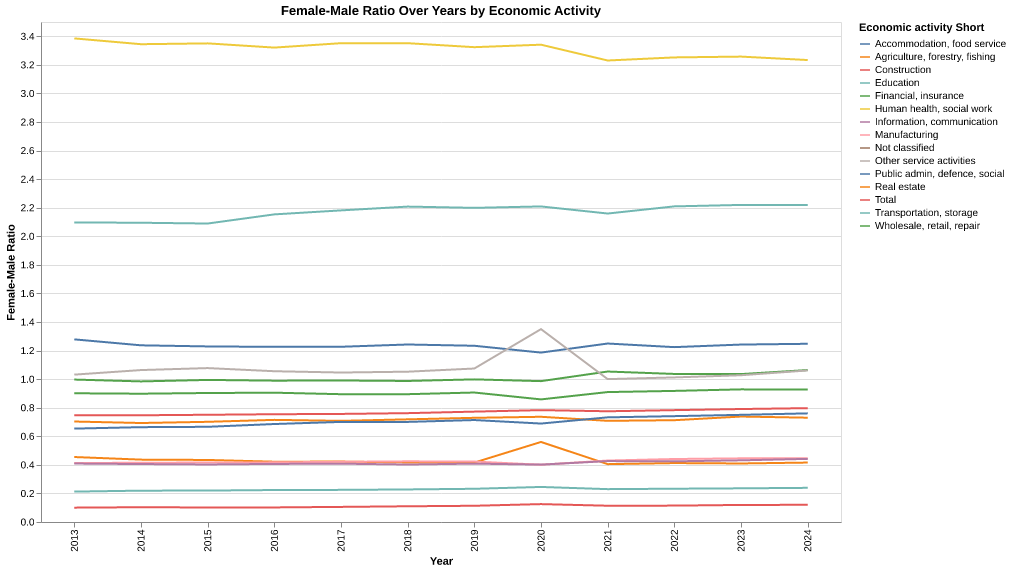

In [9]:
!pip install vl-convert-python

import altair as alt
from IPython.display import Image, display

# Create a dictionary for mapping long names to short names
activity_short_names = {
    'A. Agriculture; forestry and fishing': 'Agriculture, forestry, fishing',
    'C. Manufacturing': 'Manufacturing',
    'F. Construction': 'Construction',
    'G. Wholesale and retail trade; repair of motor vehicles and motorcycles': 'Wholesale, retail, repair',
    'H. Transportation and storage': 'Transportation, storage',
    'I. Accommodation and food service activities': 'Accommodation, food service',
    'J. Information and communication': 'Information, communication',
    'K. Financial and insurance activities': 'Financial, insurance',
    'L. Real estate activities': 'Real estate',
    'M. Professional, scientific and technical activities': 'Professional, scientific, technical',
    'N. Administrative and support service activities': 'Administrative, support service',
    'O. Public administration and defence; compulsory social security': 'Public admin, defence, social',
    'P. Education': 'Education',
    'Q. Human health and social work activities': 'Human health, social work',
    'R. Arts, entertainment and recreation': 'Arts, entertainment, recreation',
    'S. Other service activities': 'Other service activities',
    'Total': 'Total',
    'X. Not elsewhere classified': 'Not classified'
}

# Create a new column with shortened names
pivot_df['Economic activity Short'] = pivot_df['Economic activity'].map(activity_short_names)

# Create the line chart
chart = alt.Chart(pivot_df).mark_line().encode(
    x=alt.X('Year:O', title='Year'),
    y=alt.Y('Female-Male Ratio', title='Female-Male Ratio'),
    color='Economic activity Short:N',
    tooltip=['Year', 'Economic activity Short', 'Female-Male Ratio']
).properties(
    title='Female-Male Ratio Over Years by Economic Activity',
    width=800,
    height=500
).interactive()

# Save chart as PNG
chart.save("female_male_ratio_chart.png")

# Display image in notebook
display(Image("female_male_ratio_chart.png"))

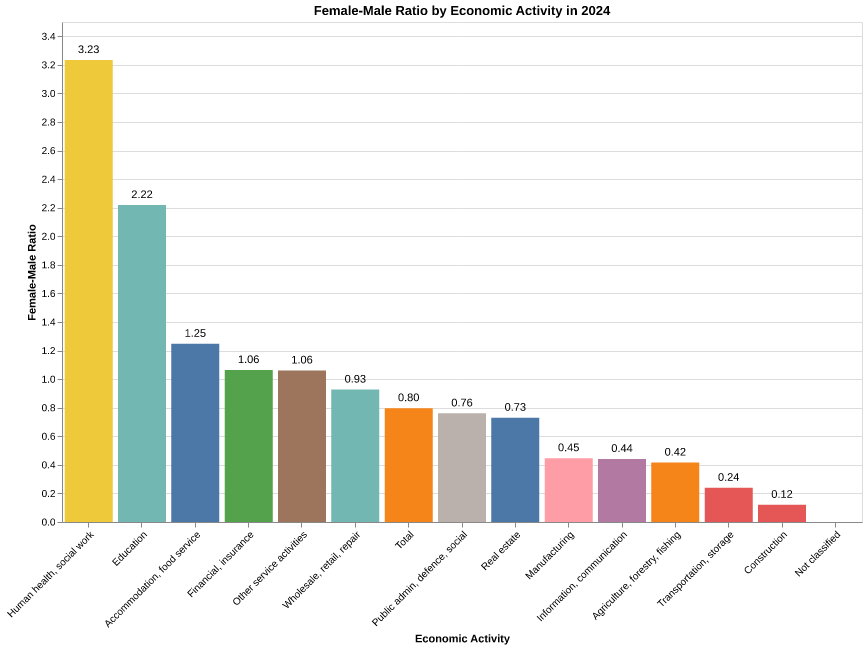

In [10]:
!pip install vl-convert-python

import altair as alt
from IPython.display import Image, display

# Filter data for the year 2024
df_2024 = pivot_df[pivot_df['Year'] == 2024]

# Sort the dataframe by Female-Male Ratio
df_2024 = df_2024.sort_values('Female-Male Ratio', ascending=False)

# Create the bar chart
chart = alt.Chart(df_2024).mark_bar().encode(
    x=alt.X(
        'Economic activity Short',
        title='Economic Activity',
        sort='-y',
        axis=alt.Axis(labelAngle=-45)
    ),
    y=alt.Y(
        'Female-Male Ratio',
        title='Female-Male Ratio'
    ),
    tooltip=[
        'Economic activity Short',
        'Female-Male Ratio'
    ],
    color=alt.Color(
        'Economic activity Short',
        legend=None
    )
).properties(
    title='Female-Male Ratio by Economic Activity in 2024',
    width=800,
    height=500
)

# Add text labels
text = chart.mark_text(
    align='center',
    baseline='bottom',
    dy=-5
).encode(
    text=alt.Text(
        'Female-Male Ratio',
        format='.2f'
    ),
    color=alt.value('black')
)

# Combine charts
final_chart = chart + text

# Save chart as PNG
final_chart.save("female_male_ratio_2024.png")

# Display image in notebook
display(Image("female_male_ratio_2024.png"))

In [12]:
import pandas as pd

# Load the Earnings CSV file
earnings_df = pd.read_csv(
    "/content/Earnings OECD INDUSTRY.csv",
    encoding='latin1'
)

# Display first rows
print("Earnings DataFrame head:")
display(earnings_df.head())

Earnings DataFrame head:


,Country,Year,Gender,ACTIVITY,Economic activity,Average monthly earnings $PPP 2021
0,Austria,2024,Total,AUT,Total,6546.981
1,Austria,2024,Total,A,A. Agriculture; forestry and fishing,5176.012
2,Austria,2024,Total,C,C. Manufacturing,7649.804
3,Austria,2024,Total,F,F. Construction,6466.382
4,Austria,2024,Total,G,G. Wholesale and retail trade; repair of motor...,5327.111


In [13]:
print(earnings_df.columns)
earnings_pivoted = earnings_df.pivot_table(index=['Country ', 'Year', 'Economic activity'], columns='Gender', values='Average monthly earnings  $PPP 2021')
earnings_pivoted['Gender Earning Gap'] = earnings_pivoted['Male'] - earnings_pivoted['Female']
earnings_pivoted = earnings_pivoted.fillna(0)
display(earnings_pivoted.head())

Index(['Country ', 'Year', 'Gender', 'ACTIVITY', 'Economic activity',
       'Average monthly earnings  $PPP 2021'],
      dtype='object')


Gender                                                              Female  \
Country  Year Economic activity                                              
Austria  2013 A. Agriculture; forestry and fishing                2470.723   
              C. Manufacturing                                    3061.090   
              F. Construction                                     3511.694   
              G. Wholesale and retail trade; repair of motor ...  2860.581   
              H. Transportation and storage                       3450.902   

Gender                                                                Male  \
Country  Year Economic activity                                              
Austria  2013 A. Agriculture; forestry and fishing                3362.570   
              C. Manufacturing                                    5219.218   
              F. Construction                                     4193.623   
              G. Wholesale and retail trade; repair of motor ...  4672.344   
              H. Transportation and storage                       4711.471   

Gender                                                               Total  \
Country  Year Economic activity                                              
Austria  2013 A. Agriculture; forestry and fishing                2996.233   
              C. Manufacturing                                    4670.376   
              F. Construction                                     4090.182   
              G. Wholesale and retail trade; repair of motor ...  3659.367   
              H. Transportation and storage                       4479.416   

Gender                                                            Gender Earning Gap  
Country  Year Economic activity                                                       
Austria  2013 A. Agriculture; forestry and fishing                           891.847  
              C. Manufacturing                                              2158.128  
              F. Construction                                                681.929  
              G. Wholesale and retail trade; repair of motor ...            1811.763  
              H. Transportation and storage                                 1260.569

In [14]:
# Filter for the year 2024
earnings_2024 = earnings_pivoted.loc[(slice(None), 2024, slice(None)), :]

# Group by Economic activity and calculate the mean of Gender Earning Gap
average_gender_earning_gap_2024 = earnings_2024.groupby('Economic activity')['Gender Earning Gap'].mean()

print("Average Gender Earning Gap by Economic Activity for 2024:")
display(average_gender_earning_gap_2024)

Average Gender Earning Gap by Economic Activity for 2024:


,Gender Earning Gap
Economic activity,
A. Agriculture; forestry and fishing,528.684897
B. Mining and quarrying,151.810333
C. Manufacturing,848.695448
"D. Electricity; gas, steam and air conditioning supply",374.183889
"E. Water supply; sewerage, waste management and remediation activities",219.244667
F. Construction,268.965310
G. Wholesale and retail trade; repair of motor vehicles and motorcycles,1068.880103
H. Transportation and storage,603.696690
I. Accommodation and food service activities,558.849586


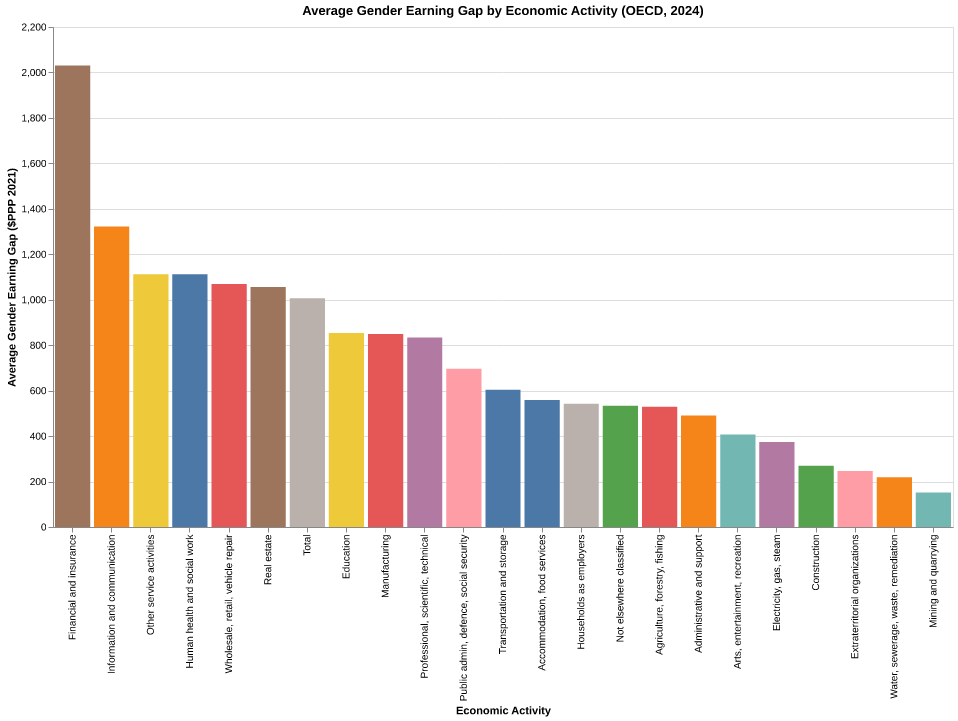

In [15]:
!pip install vl-convert-python

import altair as alt
from IPython.display import Image, display

# Convert the Series to a DataFrame for Altair
average_gender_earning_gap_2024_df = average_gender_earning_gap_2024.reset_index()
average_gender_earning_gap_2024_df.columns = [
    'Economic activity',
    'Average Gender Earning Gap'
]

# Mapping long names to short names
activity_name_map = {
    'A. Agriculture; forestry and fishing': 'Agriculture, forestry, fishing',
    'B. Mining and quarrying': 'Mining and quarrying',
    'C. Manufacturing': 'Manufacturing',
    'D. Electricity; gas, steam and air conditioning supply': 'Electricity, gas, steam',
    'E. Water supply; sewerage, waste management and remediation activities': 'Water, sewerage, waste, remediation',
    'F. Construction': 'Construction',
    'G. Wholesale and retail trade; repair of motor vehicles and motorcycles': 'Wholesale, retail, vehicle repair',
    'H. Transportation and storage': 'Transportation and storage',
    'I. Accommodation and food service activities': 'Accommodation, food services',
    'J. Information and communication': 'Information and communication',
    'K. Financial and insurance activities': 'Financial and insurance',
    'L. Real estate activities': 'Real estate',
    'M. Professional, scientific and technical activities': 'Professional, scientific, technical',
    'N. Administrative and support service activities': 'Administrative and support',
    'O. Public administration and defence; compulsory social security': 'Public admin, defence, social security',
    'P. Education': 'Education',
    'Q. Human health and social work activities': 'Human health and social work',
    'R. Arts, entertainment and recreation': 'Arts, entertainment, recreation',
    'S. Other service activities': 'Other service activities',
    'T. Activities of households as employers; undifferentiated goods- and services-producing activities of households for own use': 'Households as employers',
    'Total': 'Total',
    'U. Activities of extraterritorial organizations and bodies': 'Extraterritorial organizations',
    'X. Not elsewhere classified': 'Not elsewhere classified'
}

# Apply mapping
average_gender_earning_gap_2024_df['Economic activity'] = (
    average_gender_earning_gap_2024_df['Economic activity']
    .map(activity_name_map)
)

# Create bar chart
chart = alt.Chart(
    average_gender_earning_gap_2024_df
).mark_bar().encode(
    x=alt.X(
        'Economic activity',
        sort='-y',
        title='Economic Activity'
    ),
    y=alt.Y(
        'Average Gender Earning Gap',
        title='Average Gender Earning Gap ($PPP 2021)'
    ),
    tooltip=[
        'Economic activity',
        alt.Tooltip(
            'Average Gender Earning Gap',
            format=',.2f'
        )
    ],
    color=alt.Color(
        'Economic activity',
        legend=None
    )
).properties(
    title='Average Gender Earning Gap by Economic Activity (OECD, 2024)',
    width=900,
    height=500
).interactive()

# Save chart as PNG
chart.save("gender_earning_gap_2024.png")

# Display image in notebook
display(Image("gender_earning_gap_2024.png"))